Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
Mean: [-4.44089210e-16  2.69625592e-16 -1.11022302e-16 -2.37904934e-17]
Std: [1. 1. 1. 1.]
Confusion Matrix:
[[11  0  0]
 [ 0 15  0]
 [ 2  0 10]]
Accuracy: 94.73684210526315 %
Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92        11
           1       1.00      1.00      1.00        15
           2       1.00      0.83      0.91        12

    accuracy                           0.95        38
   macro avg       0.95      0.94      0.94        38
weighted avg       0.96      0.95      0.95        38

Predicted Species: 1


c:\Users\bda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Text(0.3333333333333333, 0.9375, 'x[3] <= -0.554\nentropy = 1.583\nsamples = 112\nvalue = [39, 35, 38]'),
 Text(0.2222222222222222, 0.8125, 'entropy = 0.0\nsamples = 35\nvalue = [0, 35, 0]'),
 Text(0.2777777777777778, 0.875, 'True  '),
 Text(0.4444444444444444, 0.8125, 'x[2] <= 0.546\nentropy = 1.0\nsamples = 77\nvalue = [39.0, 0.0, 38.0]'),
 Text(0.38888888888888884, 0.875, '  False'),
 Text(0.2222222222222222, 0.6875, 'x[3] <= 0.585\nentropy = 0.187\nsamples = 35\nvalue = [34, 0, 1]'),
 Text(0.1111111111111111, 0.5625, 'entropy = 0.0\nsamples = 34\nvalue = [34, 0, 0]'),
 Text(0.3333333333333333, 0.5625, 'entropy = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.6666666666666666, 0.6875, 'x[2] <= 0.777\nentropy = 0.527\nsamples = 42\nvalue = [5, 0, 37]'),
 Text(0.5555555555555556, 0.5625, 'x[3] <= 0.719\nentropy = 0.896\nsamples = 16\nvalue = [5, 0, 11]'),
 Text(0.3333333333333333, 0.4375, 'x[1] <= -1.587\nentropy = 0.918\nsamples = 6\nvalue = [4, 0, 2]'),
 Text(0.2222222222222222, 0.

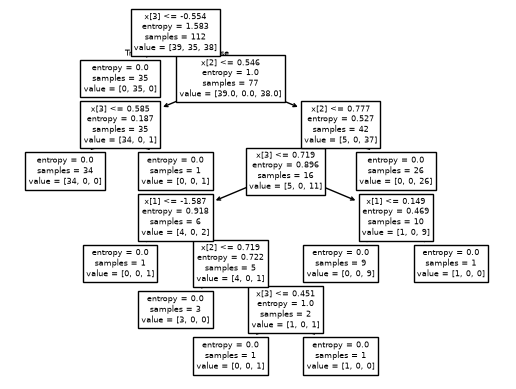

In [4]:
import numpy as np
import pandas as pd
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Load dataset
df = pd.read_csv("Iris.csv")

# Check dataset
print(df.isnull().sum())

# Features and target
X = df[
    [
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ]
]

y = df["Species"]

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

# Standardization
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Check whether StandardScaler worked
print("Mean:", X_train.mean(axis=0))
print("Std:", X_train.std(axis=0))

# Create Decision Tree classifier
classifier = DecisionTreeClassifier(
    criterion="entropy",
    random_state=0
)

# Train the model
classifier.fit(X_train, y_train)

# Predict test data
y_pred = classifier.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy * 100, "%")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))
new_flower = np.array([[
    5.1,
    3.5,
    1.4,
    0.2
]])

# Scale using the existing scaler
new_flower_scaled = sc.transform(new_flower)

# Predict
prediction = classifier.predict(new_flower_scaled)

print("Predicted Species:", prediction[0])
tree.plot_tree(classifier)
